In [1]:
!pip install qiskit==1.1
!pip install numpy
!pip install matplotlib
!pip install pylatexenc
!pip install qiskit_algorithms==0.3.1
!pip install qiskit_nature
!pip install pyscf
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 MB 15.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=2afbeb34ddd48a7a5d94ec34dc531898410aa4c54fea35dbf6758a1e93ef15c1
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import numpy as np
from qiskit import *
from qiskit_algorithms.optimizers import SPSA, SLSQP, COBYLA,CG, POWELL
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver
from qiskit_algorithms.eigensolvers import NumPyEigensolver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.mappers import BravyiKitaevMapper
from qiskit.primitives import Estimator
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import TwoLocal
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock, UCC
from qiskit.primitives import Estimator
ideal_estimator = Estimator()
from qiskit_algorithms.optimizers import L_BFGS_B,SPSA
from qiskit_algorithms import VQE
import matplotlib.pyplot as plt

The VQE energy is -7.862688941407665
The VQE energy using Twolocal is -7.861864769108462
Exact energy is -7.862919336652187
Number of qubits is 6


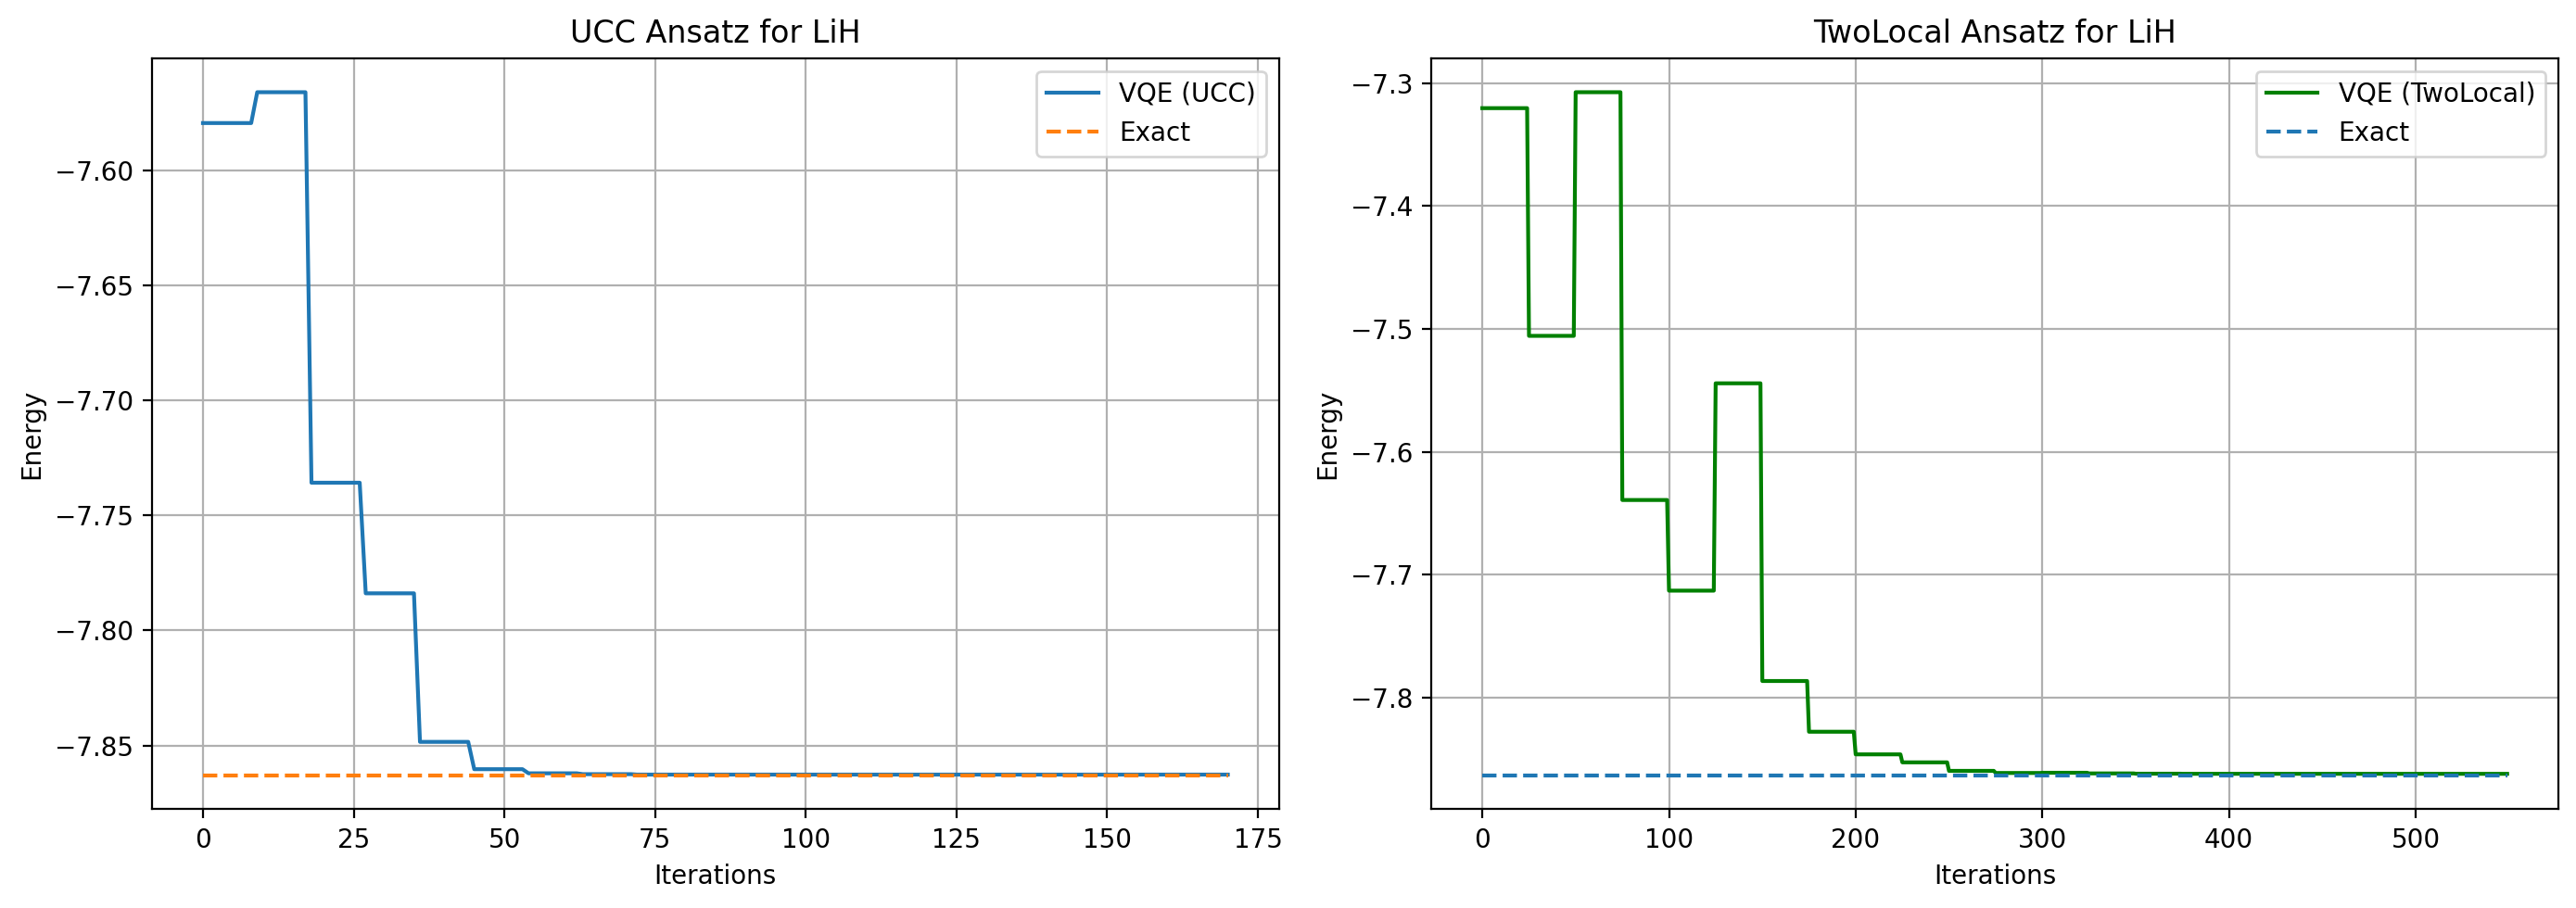

In [3]:
driver = PySCFDriver(atom=f"Li 0 0 0; H 0 0 1.6")
problem = driver.run()
hamiltonian = problem.hamiltonian
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
#Original Composition
num_particles = problem.num_particles  # This gives a tuple: (alpha_electrons, beta_electrons)
total_electrons = sum(num_particles)
num_spin_orbitals = problem.num_spin_orbitals
num_spatial_orbitals = num_spin_orbitals // 2


transformer = ActiveSpaceTransformer(2, 3) #ActiveSpaceTransformer(num_electrons, num_orbitals)
transformer.prepare_active_space(total_electrons, num_spatial_orbitals)  #transformer.prepare_active_space(num_electrons, num_molecular_orbitals/num_spatial_orbitals)


hamiltonian22 = transformer.transform_hamiltonian(hamiltonian)
repulsion = hamiltonian22.constants.get('nuclear_repulsion_energy')
active_c_energy = hamiltonian22.constants.get('ActiveSpaceTransformer')
second_q_h = hamiltonian22.second_q_op()
mapper2 = JordanWignerMapper()
hamiltonian_op = mapper2.map(second_q_h)




number_qubit2 = hamiltonian_op.num_qubits
ansatz2 = UCCSD(3,(1,1),qubit_mapper=mapper2,initial_state=HartreeFock(3, (1,1), JordanWignerMapper()))
ansatz1 = TwoLocal(num_qubits=6,rotation_blocks=['ry', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps=1)

def store_in_between_result(eval_count, parameters, mean, std):
        counts.append(eval_count)
        values.append(mean)
        params.append(parameters)
counts = []
values = []
params = []

vqe_solver2 = VQE(ideal_estimator, ansatz2, optimizer=L_BFGS_B(maxiter=100), callback=store_in_between_result)
simulation2 = vqe_solver2.compute_minimum_eigenvalue(hamiltonian_op)
energy2 = simulation2.eigenvalue + repulsion+active_c_energy


#VQE FOR Twolocal

def store_in_between_result1(eval_count, parameters, mean, std):
        counts1.append(eval_count)
        values1.append(mean)
        params1.append(parameters)
counts1 = []
values1 = []
params1 = []


vqe_solver1 = VQE(ideal_estimator, ansatz1, optimizer=L_BFGS_B(maxiter=100), callback=store_in_between_result1)
simulation1 = vqe_solver1.compute_minimum_eigenvalue(hamiltonian_op)
energy1 = simulation1.eigenvalue + repulsion+active_c_energy



print(f'The VQE energy is {energy2}')

print(f'The VQE energy using Twolocal is {energy1}')

#Exact energy
exact2 = NumPyEigensolver().compute_eigenvalues(hamiltonian_op)
exact2 = np.real(exact2.eigenvalues[0])
print(f'Exact energy is {exact2+repulsion+active_c_energy}')
print(f'Number of qubits is {number_qubit2}')


#Plotting

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5),dpi=200)  # 1 row, 2 columns

# ---- Plot 1: UCC ----
ax1.plot(values + repulsion + active_c_energy, label='VQE (UCC)')
ax1.plot((exact2 + repulsion + active_c_energy) * np.ones(len(counts)), "--", label='Exact')
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Energy')
ax1.set_title('UCC Ansatz for LiH')
ax1.grid(True)
ax1.legend()

# ---- Plot 2: TwoLocal ----
ax2.plot(values1 + repulsion + active_c_energy, label='VQE (TwoLocal)', color='green')
ax2.plot((exact2 + repulsion + active_c_energy) * np.ones(len(counts1)), "--", label='Exact')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Energy')
ax2.set_title('TwoLocal Ansatz for LiH')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

The VQE energy is -1.137283834488055
The VQE energy using Twolocal is -1.1372838343461054
Exact energy is -1.1372838344884981
Number of qubits is 6


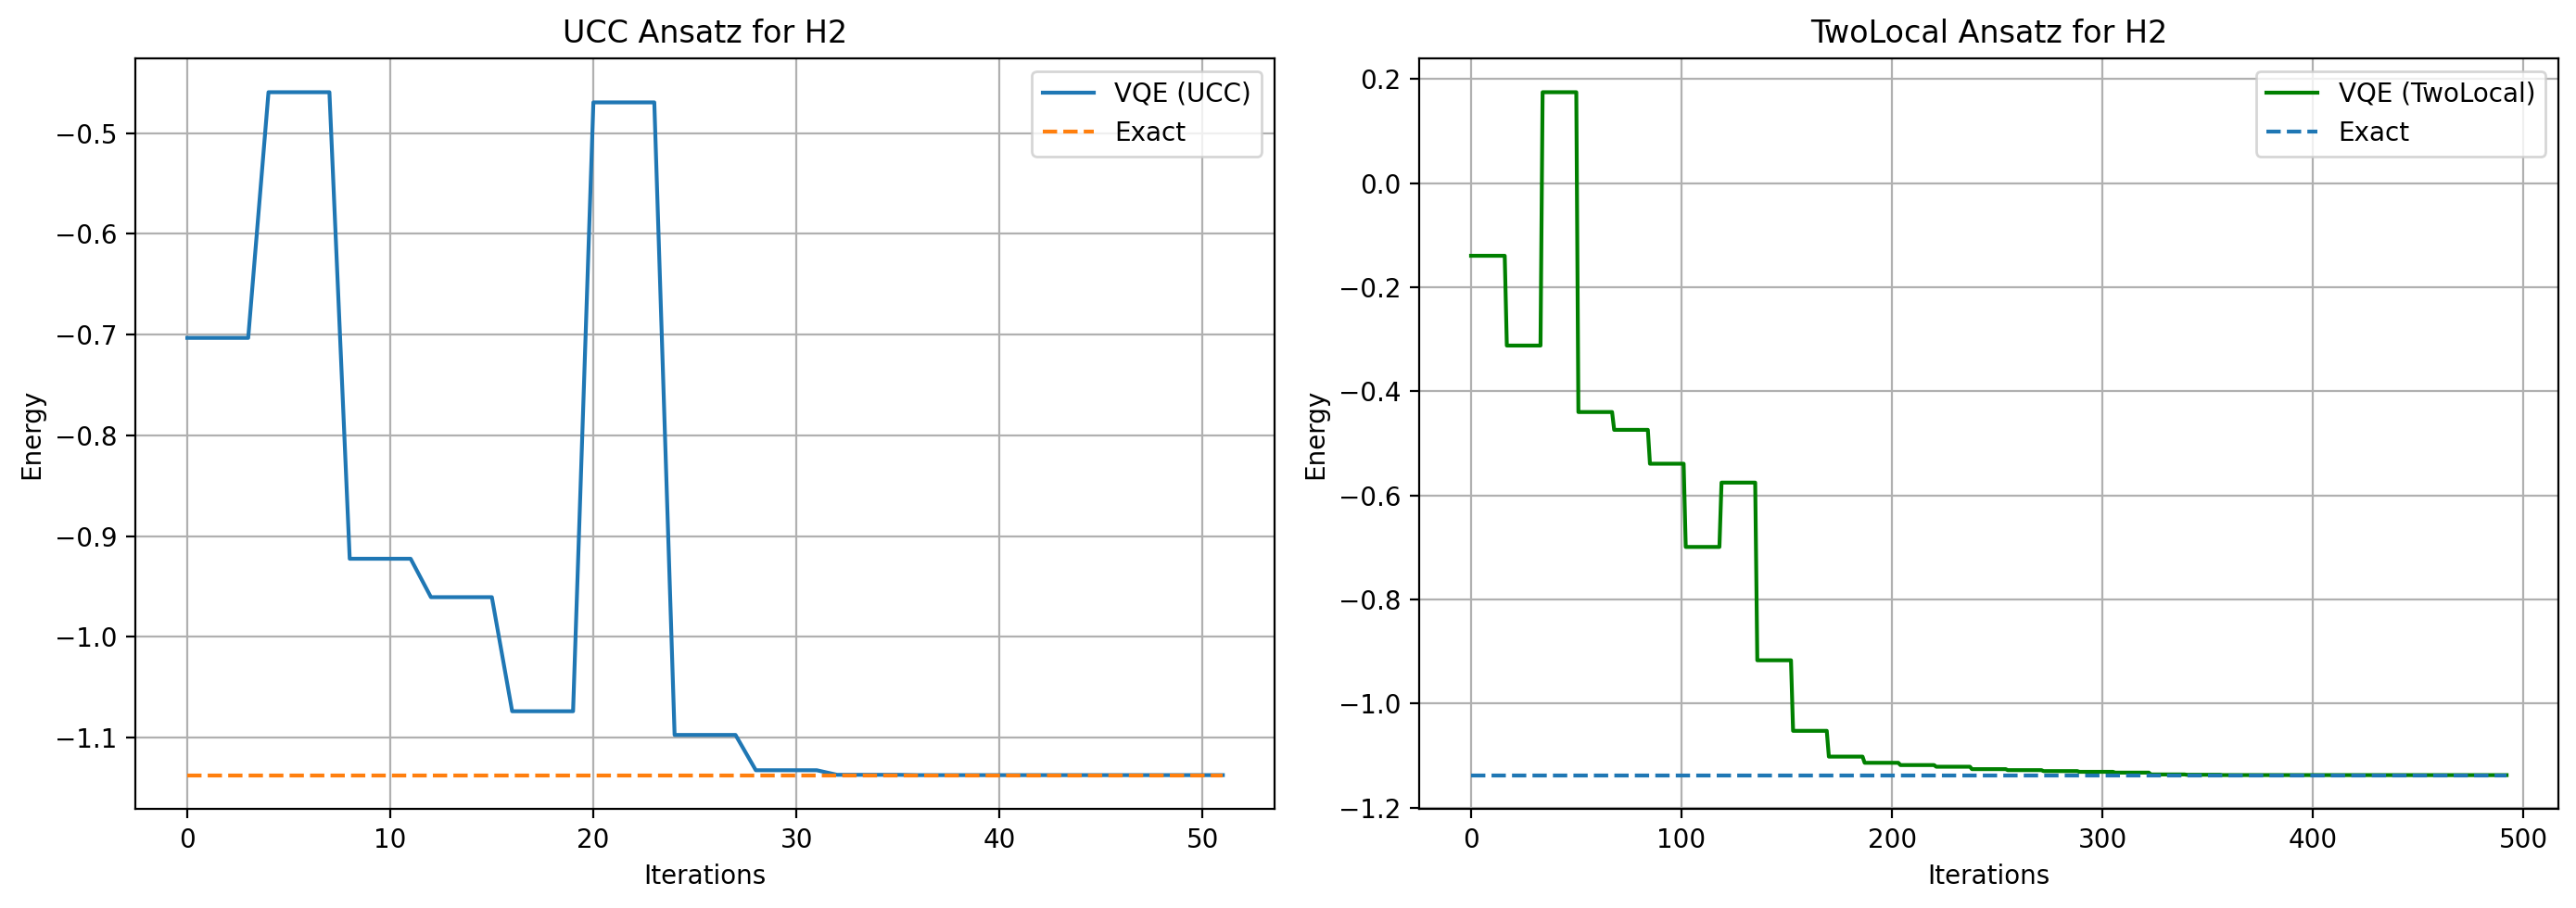

In [4]:
driver = PySCFDriver(atom=f"H 0 0 0; H 0 0 0.74")
problem = driver.run()
hamiltonian = problem.hamiltonian
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
#Original Composition
num_particles = problem.num_particles  # This gives a tuple: (alpha_electrons, beta_electrons)
total_electrons = sum(num_particles)
num_spin_orbitals = problem.num_spin_orbitals
num_spatial_orbitals = num_spin_orbitals // 2


# transformer = ActiveSpaceTransformer(2, 3) #ActiveSpaceTransformer(num_electrons, num_orbitals)
# transformer.prepare_active_space(total_electrons, num_spatial_orbitals)  #transformer.prepare_active_space(num_electrons, num_molecular_orbitals/num_spatial_orbitals)


# hamiltonian22 = transformer.transform_hamiltonian(hamiltonian)
repulsion = hamiltonian.constants.get('nuclear_repulsion_energy')
# active_c_energy = hamiltonian.constants.get('ActiveSpaceTransformer')
second_q_h = hamiltonian.second_q_op()
mapper2 = JordanWignerMapper()
hamiltonian_op = mapper2.map(second_q_h)




# number_qubit2 = hamiltonian_op.num_qubits
ansatz2 = UCCSD(2,(1,1),qubit_mapper=mapper2,initial_state=HartreeFock(2, (1,1), JordanWignerMapper()))
ansatz1 = TwoLocal(num_qubits=4,rotation_blocks=['ry', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps=1)

def store_in_between_result(eval_count, parameters, mean, std):
        counts.append(eval_count)
        values.append(mean)
        params.append(parameters)
counts = []
values = []
params = []

vqe_solver2 = VQE(ideal_estimator, ansatz2, optimizer=L_BFGS_B(maxiter=100), callback=store_in_between_result)
simulation2 = vqe_solver2.compute_minimum_eigenvalue(hamiltonian_op)
energy2 = simulation2.eigenvalue + repulsion


#VQE FOR Twolocal

def store_in_between_result1(eval_count, parameters, mean, std):
        counts1.append(eval_count)
        values1.append(mean)
        params1.append(parameters)
counts1 = []
values1 = []
params1 = []


vqe_solver1 = VQE(ideal_estimator, ansatz1, optimizer=L_BFGS_B(maxiter=100), callback=store_in_between_result1)
simulation1 = vqe_solver1.compute_minimum_eigenvalue(hamiltonian_op)
energy1 = simulation1.eigenvalue + repulsion



print(f'The VQE energy is {energy2}')

print(f'The VQE energy using Twolocal is {energy1}')

#Exact energy
exact2 = NumPyEigensolver().compute_eigenvalues(hamiltonian_op)
exact2 = np.real(exact2.eigenvalues[0])
print(f'Exact energy is {exact2+repulsion}')
print(f'Number of qubits is {number_qubit2}')


#Plotting

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5),dpi=200)  # 1 row, 2 columns

# ---- Plot 1: UCC ----
ax1.plot(values + repulsion , label='VQE (UCC)')
ax1.plot((exact2 + repulsion ) * np.ones(len(counts)), "--", label='Exact')
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Energy')
ax1.set_title('UCC Ansatz for H2')
ax1.grid(True)
ax1.legend()

# ---- Plot 2: TwoLocal ----
ax2.plot(values1 + repulsion , label='VQE (TwoLocal)', color='green')
ax2.plot((exact2 + repulsion ) * np.ones(len(counts1)), "--", label='Exact')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Energy')
ax2.set_title('TwoLocal Ansatz for H2')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

6
6
6
The VQE energy using UCC is -74.96463706338669
The VQE energy using Twolocal is -74.96306312925938
Exact energy is -74.96463706338814
Number of qubits is 6


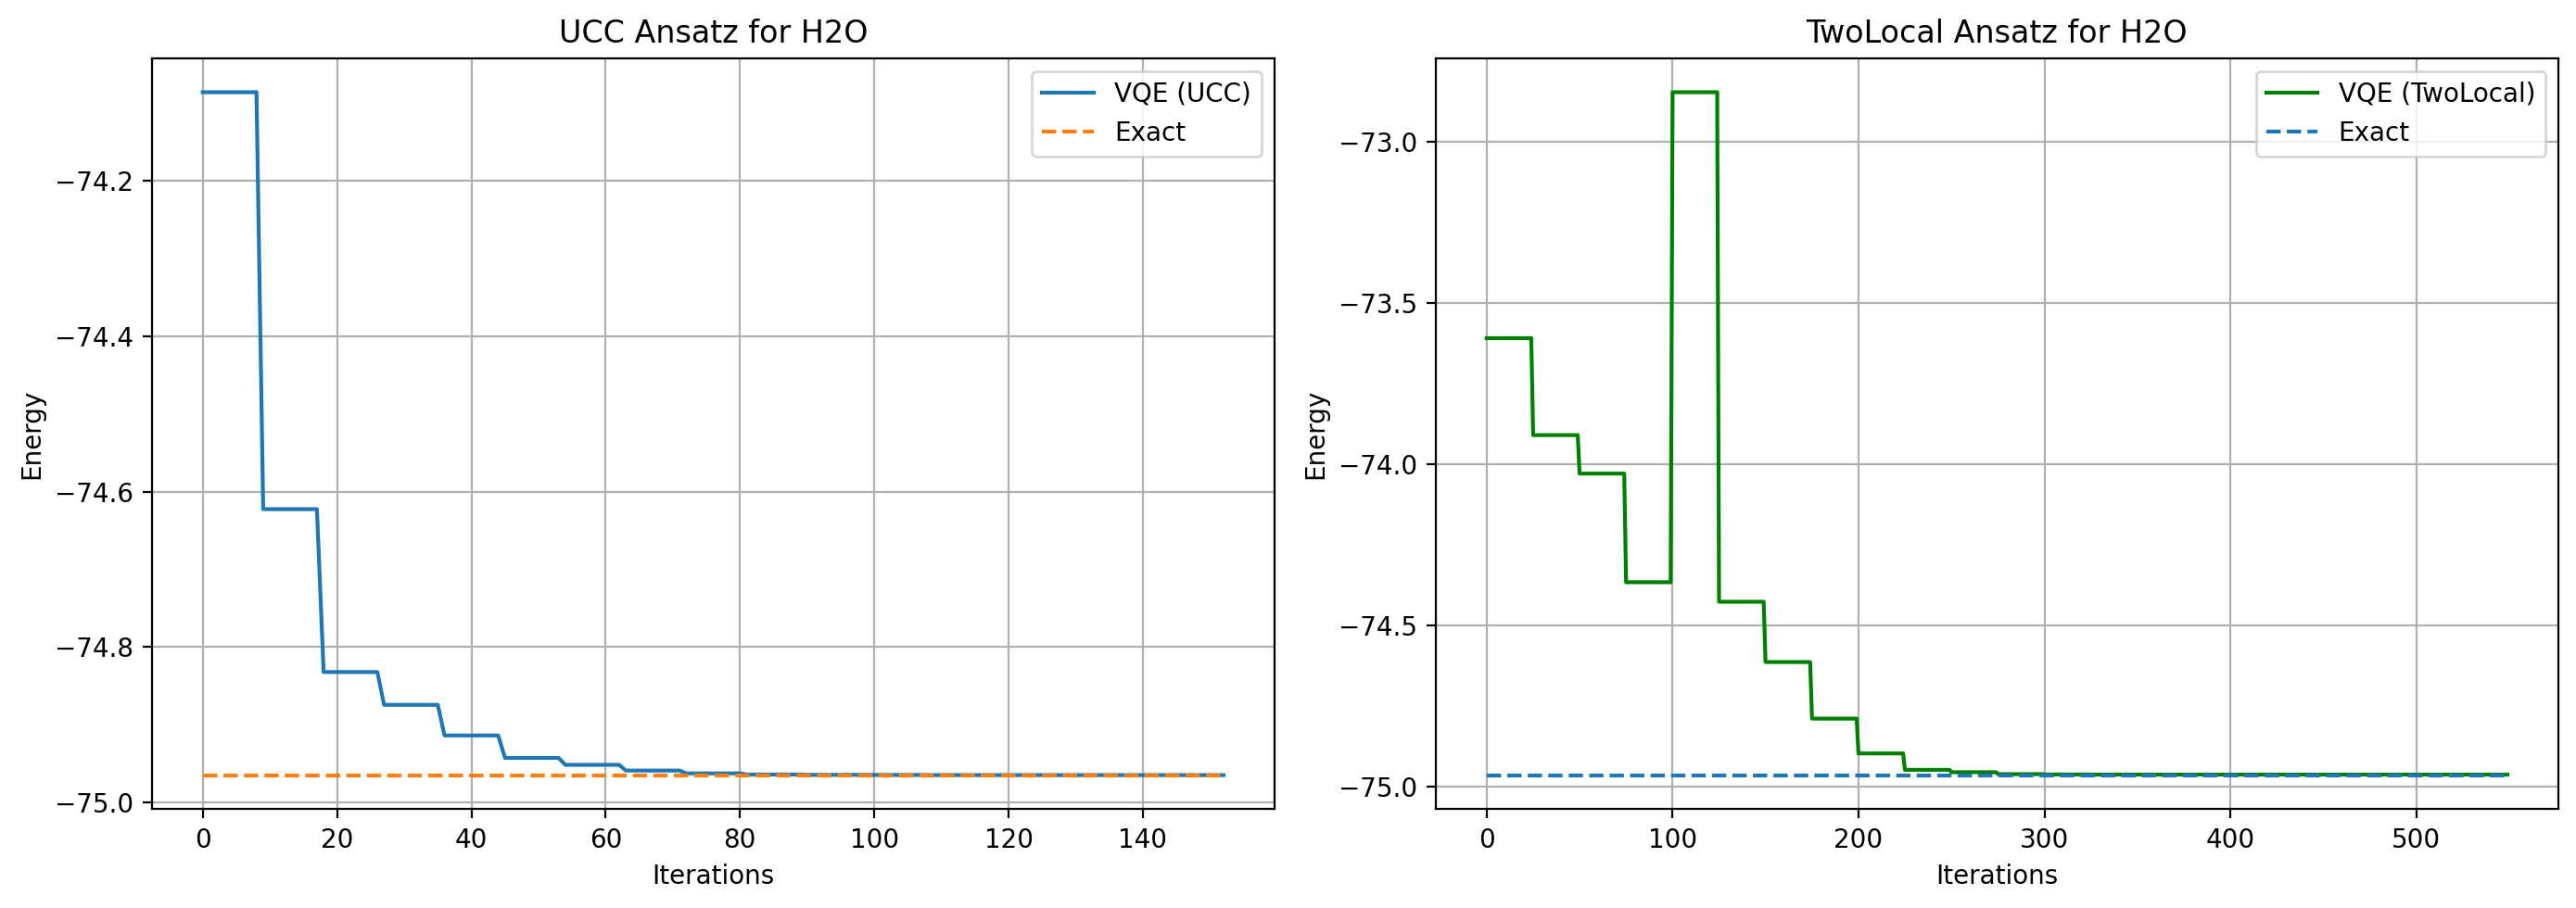

In [20]:
driver = PySCFDriver(atom=f"O 0.0000 0.0000 0.0000; H 0.0000 -0.7570 0.5870; H 0.0000 0.7570 0.5870")
problem = driver.run()
hamiltonian = problem.hamiltonian
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
#Original Composition
num_particles = problem.num_particles  # This gives a tuple: (alpha_electrons, beta_electrons)
total_electrons = sum(num_particles)
num_spin_orbitals = problem.num_spin_orbitals
num_spatial_orbitals = num_spin_orbitals // 2


transformer = ActiveSpaceTransformer(2,3) #ActiveSpaceTransformer(num_electrons, num_orbitals)
transformer.prepare_active_space(total_electrons, num_spatial_orbitals)  #transformer.prepare_active_space(num_electrons, num_molecular_orbitals/num_spatial_orbitals)


hamiltonian22 = transformer.transform_hamiltonian(hamiltonian)
repulsion = hamiltonian22.constants.get('nuclear_repulsion_energy')
active_c_energy = hamiltonian22.constants.get('ActiveSpaceTransformer')
second_q_h = hamiltonian22.second_q_op()
mapper2 = JordanWignerMapper()
hamiltonian_op = mapper2.map(second_q_h)




number_qubit2 = hamiltonian_op.num_qubits
ansatz2 = UCCSD(3,(1,1),qubit_mapper=mapper2,initial_state=HartreeFock(3, (1,1), JordanWignerMapper()))
ansatz1 = TwoLocal(num_qubits=6,rotation_blocks=['ry', 'rz'], entanglement_blocks=['cx'], entanglement='linear', reps=1)
print(ansatz1.num_qubits)
print(ansatz2.num_qubits)
print(hamiltonian_op.num_qubits)

def store_in_between_result(eval_count, parameters, mean, std):
        counts.append(eval_count)
        values.append(mean)
        params.append(parameters)
counts = []
values = []
params = []

vqe_solver2 = VQE(ideal_estimator, ansatz2, optimizer=L_BFGS_B(maxiter=100), callback=store_in_between_result)
simulation2 = vqe_solver2.compute_minimum_eigenvalue(hamiltonian_op)
energy2 = simulation2.eigenvalue + repulsion+active_c_energy


#VQE FOR Twolocal

def store_in_between_result1(eval_count, parameters, mean, std):
        counts1.append(eval_count)
        values1.append(mean)
        params1.append(parameters)
counts1 = []
values1 = []
params1 = []


vqe_solver1 = VQE(ideal_estimator, ansatz1, optimizer=L_BFGS_B(maxiter=100), callback=store_in_between_result1)
simulation1 = vqe_solver1.compute_minimum_eigenvalue(hamiltonian_op)
energy1 = simulation1.eigenvalue + repulsion+active_c_energy



print(f'The VQE energy using UCC is {energy2}')

print(f'The VQE energy using Twolocal is {energy1}')

#Exact energy
exact2 = NumPyEigensolver().compute_eigenvalues(hamiltonian_op)
exact2 = np.real(exact2.eigenvalues[0])
print(f'Exact energy is {exact2+repulsion+active_c_energy}')
print(f'Number of qubits is {number_qubit2}')


#Plotting

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5),dpi=200)  # 1 row, 2 columns

# ---- Plot 1: UCC ----
ax1.plot(values + repulsion + active_c_energy, label='VQE (UCC)')
ax1.plot((exact2 + repulsion + active_c_energy) * np.ones(len(counts)), "--", label='Exact')
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Energy')
ax1.set_title('UCC Ansatz for H2O')
ax1.grid(True)
ax1.legend()

# ---- Plot 2: TwoLocal ----
ax2.plot(values1 + repulsion + active_c_energy, label='VQE (TwoLocal)', color='green')
ax2.plot((exact2 + repulsion + active_c_energy) * np.ones(len(counts1)), "--", label='Exact')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Energy')
ax2.set_title('TwoLocal Ansatz for H2O')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()